In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 100)

import warnings
warnings.filterwarnings("ignore")

from imblearn.combine import SMOTETomek
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier

!pip install lightgbm
from lightgbm import LGBMClassifier

from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, PrecisionRecallDisplay, f1_score, precision_score, recall_score, roc_curve, auc, fbeta_score, precision_recall_curve, average_precision_score, confusion_matrix_display

In [ ]:
# Loading the dataset
from google.colab import files
uploaded = files.upload()

Saving train_dataset_final1.csv to train_dataset_final1.csv
Saving validate_dataset_final.csv to validate_dataset_final.csv


In [69]:
# Reading the dataset
df=pd.read_csv('train_dataset_final1.csv')
df_valid=pd.read_csv('validate_dataset_final.csv')

In [ ]:
# This function handles missing 'age' values, drops 'Customer_ID', and renames 'education' and 'marriage' values.

def clean_and_transform(df):
    # Drop rows with missing 'age'
    df = df.dropna(subset=['age'])

    # Drop the 'Customer_ID' column
    if "Customer_ID" in df.columns:
        df.drop(["Customer_ID"], axis=1, inplace=True)

    # Replace values in 'education' column
    df['education'].replace({0:4, 5:4, 6:4}, inplace=True)

    # Replace values in 'marriage' column
    df['marriage'].replace({0:3}, inplace=True)

    return df

In [ ]:
# Define lists of column names for payment, bill amounts, and payment amounts.

pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
bill_cols = ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']
pay_amt_cols = ['pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

In [ ]:
# This function creates new features based on the existing payment and billing columns.

def feature_engineering_final(df):

  df['Credit_Utilization_Ratio_avg'] = (df[bill_cols].sum(axis=1) / len(bill_cols)) / df['LIMIT_BAL']

  df['Delinquency_Streak'] = df[pay_cols].apply(
        lambda row: np.max(np.split(row.values >= 1, np.where(~(row.values >= 1))[0])[0].sum() if np.any(row.values >= 1) else 0, axis=0),
        axis=1)

  df['Num_Delayed_Payments'] = (df[pay_cols] > 0).sum(axis=1)

  df['Recent_Overdue_Count'] = (df[['pay_0', 'pay_2', 'pay_3']] > 0).sum(axis=1)

  df['Max_Delay_Months'] = df[pay_cols].max(axis=1)

  df['MaxDelay_to_Limit_ratio'] = df['Max_Delay_Months'] / df['LIMIT_BAL']

  df['Payment_Volatility'] = df[pay_cols].std(axis=1).fillna(0)

  total_bill_sum = df[bill_cols].sum(axis=1)
  total_payment_sum = df[pay_cols].sum(axis=1)
  df['Total_Payment_to_Total_Bill'] = np.where(total_bill_sum != 0, total_payment_sum / total_bill_sum, 0)

  df['Utilization_Payment_Interaction'] = df['Credit_Utilization_Ratio_avg'] * df['Total_Payment_to_Total_Bill']

  return df

In [ ]:
df=clean_and_transform(df)

In [ ]:
df=feature_engineering_final(df)

In [ ]:
X = df.drop(['next_month_default'], axis=1)

y = df['next_month_default']

In [ ]:
# Train-test split

# Splitting the data into training and testing sets with a 80/20 split.
# Stratification is used to maintain the original distribution of the target variable in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# Used SMOTETomek to balance the '1' class.
smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

Random Forest Results:
Accuracy: 0.8035820895522388
AUC: 0.7666071764332368
F2 Score: 0.5396341463414634
              precision    recall  f1-score   support

           0     0.8917    0.8621    0.8766      4068
           1     0.4863    0.5549    0.5183       957

    accuracy                         0.8036      5025
   macro avg     0.6890    0.7085    0.6975      5025
weighted avg     0.8145    0.8036    0.8084      5025



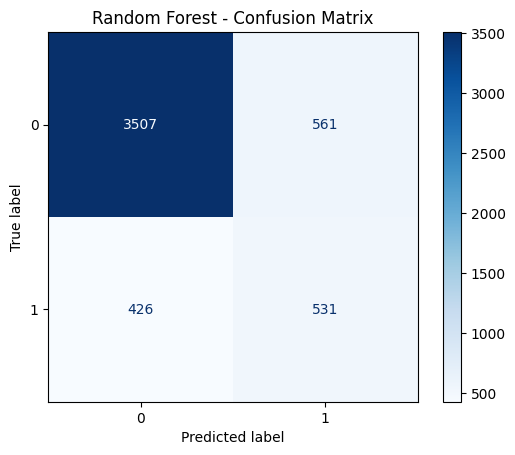


XGBoost Results:
Accuracy: 0.8208955223880597
AUC: 0.7626095663172258
F2 Score: 0.43120473996050035
              precision    recall  f1-score   support

           0     0.8687    0.9174    0.8924      4068
           1     0.5391    0.4107    0.4662       957

    accuracy                         0.8209      5025
   macro avg     0.7039    0.6640    0.6793      5025
weighted avg     0.8059    0.8209    0.8112      5025



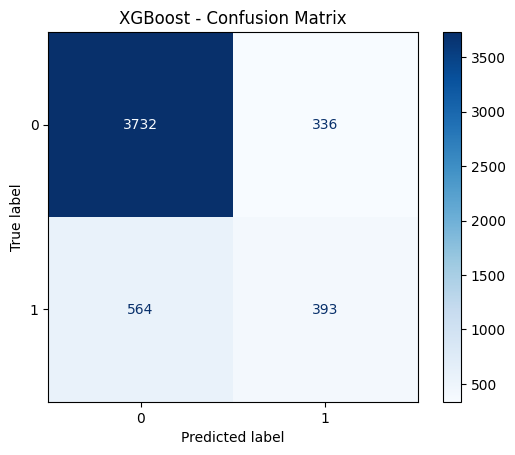

[LightGBM] [Info] Number of positive: 15895, number of negative: 15895
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023879 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5453
[LightGBM] [Info] Number of data points in the train set: 31790, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

LightGBM Results:
Accuracy: 0.828457711442786
AUC: 0.7670024936579712
F2 Score: 0.4228800356109504
              precision    recall  f1-score   support

           0     0.8677    0.9299    0.8977      4068
           1     0.5714    0.3971    0.4686       957

    accuracy                         0.8285      5025
   macro avg     0.7195    0.6635    0.6831      5025
weighted avg     0.8112    0.8285    0.8160      5025



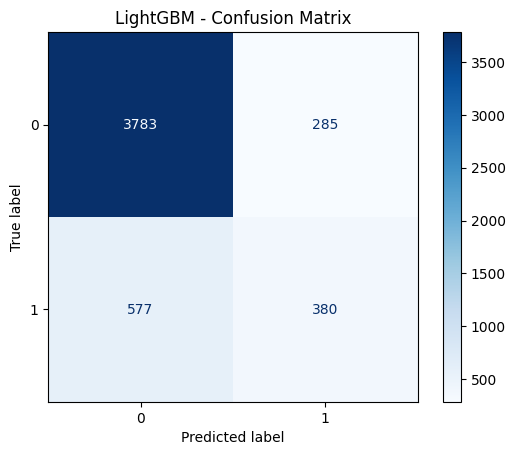

In [71]:
# Used RandomForest, XGBoost, LightGBM models for classification purpose.
# RandomForest
rfc = RandomForestClassifier(
    n_estimators=800,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)
y_proba_rfc = rfc.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("AUC:", roc_auc_score(y_test, y_proba_rfc))
print("F2 Score:", fbeta_score(y_test, y_pred_rfc, beta=2))
print(classification_report(y_test, y_pred_rfc, digits=4))

# Confusion Matrix for RFC
disp = ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test, cmap=plt.cm.Blues)
plt.title("Random Forest - Confusion Matrix")
plt.show()

# XGBoost
xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_alpha=0.5,
    reg_lambda=1.0,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("\nXGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_proba_xgb))
print("F2 Score:", fbeta_score(y_test, y_pred_xgb, beta=2))
print(classification_report(y_test, y_pred_xgb, digits=4))

# Confusion Matrix for XGB
disp = ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test, cmap=plt.cm.Blues)
plt.title("XGBoost - Confusion Matrix")
plt.show()

# LightGBM
lgb = LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=24,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.3,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42
)
lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_test)
y_proba_lgb = lgb.predict_proba(X_test)[:, 1]

print("\nLightGBM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("AUC:", roc_auc_score(y_test, y_proba_lgb))
print("F2 Score:", fbeta_score(y_test, y_pred_lgb, beta=2))
print(classification_report(y_test, y_pred_lgb, digits=4))

# Confusion Matrix for LGBM
disp = ConfusionMatrixDisplay.from_estimator(lgb, X_test, y_test, cmap=plt.cm.Blues)
plt.title("LightGBM - Confusion Matrix")
plt.show()

Since RandomForest performed best among the three, so we'll try to optimize its parameters for better results.

In [55]:
final_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
#model.fit(X_train, y_train)
#model = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
final_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=3,
                       min_samples_split=5, n_estimators=800, n_jobs=-1,
                       random_state=42)

In [56]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

Accuracy: 0.8035820895522388
AUC: 0.7666071764332368
F2 Score: 0.5396341463414634
F1 Score: 0.5183016105417276

Classification Report:
               precision    recall  f1-score   support

           0     0.8917    0.8621    0.8766      4068
           1     0.4863    0.5549    0.5183       957

    accuracy                         0.8036      5025
   macro avg     0.6890    0.7085    0.6975      5025
weighted avg     0.8145    0.8036    0.8084      5025



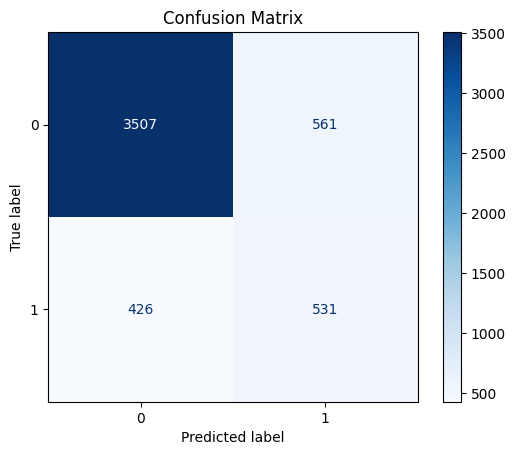

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))
print("F2 Score:", fbeta_score(y_test, y_pred, beta=2))
print("F1 Score:", fbeta_score(y_test, y_pred, beta=1))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score, accuracy_score, classification_report
import numpy as np

# Fit RandomForest model again if needed
rfc.fit(X_train, y_train)

# Predict probabilities on test set
y_proba_test = rfc.predict_proba(X_test)[:, 1]

# Calculate precision-recall pairs for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# Calculate F2 scores for all thresholds
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-8)

# Find threshold that maximizes F2
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f"Optimal Threshold for F2: {best_threshold:.4f}")
print(f"Best F2 Score on Test: {best_f2:.4f}")

# Make predictions using optimal threshold
y_test_pred = (y_proba_test >= best_threshold).astype(int)

# Evaluate with optimized threshold
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("AUC:", roc_auc_score(y_test, y_proba_test))
print("F2 Score:", fbeta_score(y_test, y_test_pred, beta=2))
print(classification_report(y_test, y_test_pred, digits=4))

Optimal Threshold for F2: 0.2711
Best F2 Score on Test: 0.5945
Accuracy: 0.64636815920398
AUC: 0.7666071764332368
F2 Score: 0.5944571990816662
              precision    recall  f1-score   support

           0     0.9158    0.6202    0.7396      4068
           1     0.3194    0.7576    0.4493       957

    accuracy                         0.6464      5025
   macro avg     0.6176    0.6889    0.5944      5025
weighted avg     0.8022    0.6464    0.6843      5025



Optimizing solely for F2 led to a significantly lower threshold, which reduced accuracy from ~81% to ~64%, with only marginal gains in F2. Therefore, we selected a balanced approach—maintaining a reasonable trade-off between accuracy and F2, while considering overall model performance across all key metrics.

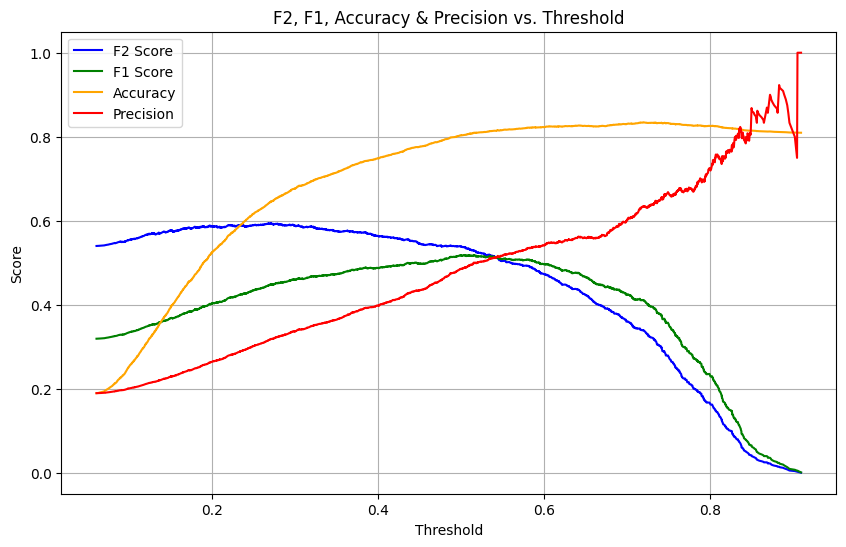

Threshold maximizing F2: 0.2711 | F2: 0.5945 | Accuracy: 0.6464 | Precision: 0.3194
              precision    recall  f1-score   support

           0     0.9158    0.6202    0.7396      4068
           1     0.3194    0.7576    0.4493       957

    accuracy                         0.6464      5025
   macro avg     0.6176    0.6889    0.5944      5025
weighted avg     0.8022    0.6464    0.6843      5025



In [ ]:
from sklearn.metrics import precision_recall_curve, fbeta_score, f1_score, accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Predict probabilities on test set
y_proba_test = rfc.predict_proba(X_test)[:, 1]

# Generate Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)

# Initialize lists to store metrics for each threshold
f2_scores = []
f1_scores = []
accuracies = []
precisions_list = []

for thresh in thresholds:
    y_pred = (y_proba_test >= thresh).astype(int)
    f2_scores.append(fbeta_score(y_test, y_pred, beta=2))
    f1_scores.append(f1_score(y_test, y_pred))
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions_list.append(precision_score(y_test, y_pred))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f2_scores, label='F2 Score', color='blue')
plt.plot(thresholds, f1_scores, label='F1 Score', color='green')
plt.plot(thresholds, accuracies, label='Accuracy', color='orange')
plt.plot(thresholds, precisions_list, label='Precision', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('F2, F1, Accuracy & Precision vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Show threshold that maximizes F2
best_idx = np.argmax(f2_scores)
print(f"Threshold maximizing F2: {thresholds[best_idx]:.4f} | F2: {f2_scores[best_idx]:.4f} | Accuracy: {accuracies[best_idx]:.4f} | Precision: {precisions_list[best_idx]:.4f}")

# Evaluate using best threshold for F2 (optional)
y_test_pred = (y_proba_test >= thresholds[best_idx]).astype(int)
print(classification_report(y_test, y_test_pred, digits=4))

From the plot, it’s evident that the default threshold (0.5) provides a reasonable balance across all key metrics. Since it delivers consistent and acceptable performance, we retained the default cutoff.

In [70]:
validation_ids = df_valid['Customer_ID']

df_valid=clean_and_transform(df_valid)
df_valid=feature_engineering_final(df_valid)

valid_predictions = final_model.predict(df_valid)

result_df = pd.DataFrame({
    'ID':validation_ids ,
    'Prediction': valid_predictions
})

output_file = 'credit_default_predictions.csv'
result_df.to_csv(output_file, index=False)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>